In [ ]:
import torch
import torch.nn as nn

# 再現性を確保するために乱数シードを42に固定（初期値による結果のブレを防止
torch.manual_seed(42)

In [ ]:
# 入力データ X: 5つのサンプルデータ（1次元の特徴量）
# 全結合層(nn.Linear)に入力するため、(サンプル数, 特徴量数) = (5, 1) の2次元形状にする
X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])
# 教師データ y: 各 X に対する正解ラベル
# 真の関係式 y = 2x + 1 に基づく値。Xと同様に (5, 1) の形状を保持する
y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0],
])
# テンソルの内容を出力（値とデータ型 dtype=torch.float32 などが確認できる）
print(X)
print(y)

# テンソルの形状（次元）を確認
# 出力結果: torch.Size([5, 1])
print("X.shape:", X.shape)
print("y.shape:", y.shape)

tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])
tensor([[ 3.],
        [ 5.],
        [ 7.],
        [ 9.],
        [11.]])
X.shape: torch.Size([5, 1])
y.shape: torch.Size([5, 1])


In [ ]:
# nn.Module を継承して自作の線形回帰モデルクラスを作成
class LinearModel(nn.Module):

    def __init__(self):
        # 親クラス(nn.Module)のコンストラクタを呼び出して初期化
        super().__init__()
        # 1次元入力 -> 1次元出力 の全結合層(線形層)を定義
    # 内部的に 重み w (shape: [1, 1]) と バイアス b (shape: [1]) が乱数で初期化される
        self.linear = nn.Linear(
            in_features=1,　# 入力データ X の特徴量の数（列数）
            out_features=1　# 出力データ y の特徴量の数（列数）
        )

    def forward(self, x):
        # 順伝播処理: 入力 x を線形層に通して予測値を返す
        return self.linear(x)

In [ ]:
# LinearModel クラスからモデルのインスタンスを生成
# この瞬間に内部の重み(weight)とバイアス(bias)が初期化される
model = LinearModel()

# モデルのレイヤー構成を表示
# 出力結果から、in_features=1, out_features=1 の全結合層が含まれていることが確認できる
print(model)


LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
# model.named_parameters() を使うことで、
# モデル内のすべての学習対象パラメータの名前(name)と値(param)を順に取り出す
for name, param in model.named_parameters():
    # パラメータの変数名を表示（例: "linear.weight", "linear.bias"）
    print(name)
    # パラメータの値（テンソル）を表示
  　# 初期化直後のため、ランダムな初期値が表示される
  　# requires_grad=True は勾配計算（学習）の対象であることを示す
    print(param)

linear.weight
Parameter containing:
tensor([[0.7645]], requires_grad=True)
linear.bias
Parameter containing:
tensor([0.8300], requires_grad=True)


In [ ]:
# 未学習のモデルに入力データ X (5, 1) を与えて予測値を出力
# 内部的に LinearModel の forward メソッドが呼び出される
predictions = model(X)

# 予測結果を表示
# 計算グラフが追跡されているため、値とともに grad_fn 属性（計算履歴）も確認できる
print(predictions)


tensor([[1.5945],
        [2.3591],
        [3.1236],
        [3.8882],
        [4.6527]], grad_fn=<AddmmBackward0>)


In [ ]:
# 損失関数（Loss Function）として平均二乗誤差（MSE: Mean Squared Error）を定義
# 予測値と正解値の差（誤差）を二乗した平均を計算し、モデルの予測精度の悪さを数値化する
loss_fn = nn.MSELoss()

In [ ]:
# 最新の重み・バイアスを用いて入力 X に対する予測値を算出
predictions = model(X)

# 予測値 (predictions) と正解データ (y) の差を MSE で計算し、損失値(loss)を取得
loss = loss_fn(predictions, y)
# 計算された損失値を表示（モデルの現在の「予測の精度の悪さ」が数値で確認できる）
print(loss)

tensor(18.0790, grad_fn=<MseLossBackward0>)


In [ ]:
# 確率的勾配降下法（SGD）オプティマイザを定義
# model.parameters(): 更新対象である重み w とバイアス b をオプティマイザに登録
# lr=0.05: 学習率（1回の更新でパラメータを動かすステップサイズ）を設定
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05
)

/opt/anaconda3/lib/python3.12/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [ ]:
# エポック数（全データを使った学習の繰り返し回数）を設定
epochs = 500

for epoch in range(epochs):

    # 1. 勾配の初期化
  　# PyTorchの仕様上、勾配は累積されるため、各ステップの最初に 0 にリセットする
    optimizer.zero_grad()

    # 2. 順伝播（Forward Pass）
  　# 現在の重み・バイアスを用いてモデルの予測値を計算
    predictions = model(X)

    # 3. 損失（Loss）の計算
  　# 予測値と正解データの誤差を MSE（平均二乗誤差）で算出
    loss = loss_fn(predictions, y)

    # 4. 逆伝播（Backward Pass）
    # 計算グラフを遡り、各パラメータ(w, b)における勾配（微分値）を自動算出
    loss.backward()

    # 5. パラメータ更新: 算出された勾配と学習率(lr=0.05)に基づいて w と b を更新
    optimizer.step()

    # 50エポックごとに現在の損失値を出力（進捗確認）
    if epoch % 50 == 0:
        # loss.item() でテンソルから数値(float)だけを取り出して表示
        print(
            f"Epoch: {epoch}, "
            f"loss: {loss.item():.6f}"
            )

Epoch: 0, loss: 18.079025
Epoch: 50, loss: 0.000846
Epoch: 100, loss: 0.000154
Epoch: 150, loss: 0.000028
Epoch: 200, loss: 0.000005
Epoch: 250, loss: 0.000001
Epoch: 300, loss: 0.000000
Epoch: 350, loss: 0.000000
Epoch: 400, loss: 0.000000
Epoch: 450, loss: 0.000000


In [ ]:
# 学習完了後のパラメータ（w と b）を確認
# y = 2X + 1 の通り、w ≈ 2.0、b ≈ 1.0 に近づいていれば成功！

for name, param in model.named_parameters():
    print(name, param.data)

linear.weight tensor([[2.0000]])
linear.bias tensor([1.0000])


In [ ]:
# 未知の入力データ X = 10.0 を定義
# モデルの入力形式 (バッチサイズ, 特徴量数) に合わせ、(1, 1) の2次元テンソルにする
new_x = torch.tensor([[10.0]])

# 推論モード: 勾配の追跡・保存をオフにしてメモリを節約＆計算を高速化
with torch.no_grad():
    prediction = model(new_x)
# 予測結果を出力（y = 2*(10) + 1 = 21.0 に近い値が得られる）
print(prediction)

tensor([[20.9999]])


lr=0.001final loss=0.00538197
lr=0.01 final loss=0.00120959
lr=0.1  final loss=inf
lr=0.5  final loss=nan
lr=1.0  final loss=nan


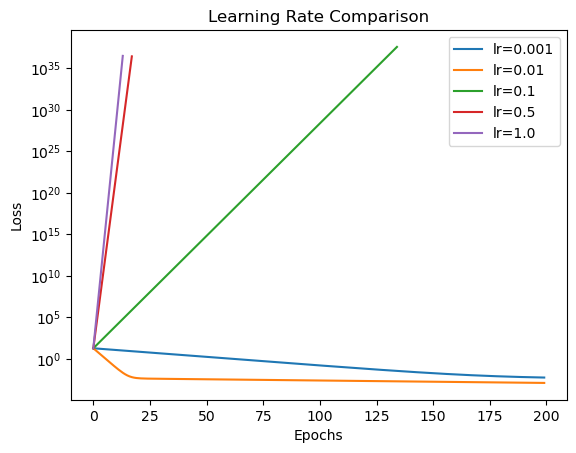

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- 1. データセットの準備 ---
X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0]
])

# --- 2. モデル定義 ---
class LinearModel(nn.Module):

    def __init__(self):
        super().__init__()
        # 入力1次元 -> 出力1次元の全結合層 (y = w*x + b)
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# --- 3. 学習率（lr）比較実験の設定 ---
# 様々な学習率(lr)での学習挙動を比較する実験
learning_rate = [0.001, 0.01, 0.1, 0.5, 1.0]
epochs = 200

# 各学習率ごとの損失推移（lossの履歴）を保存する辞書
all_losses = {}

# 各学習率で独立して学習を実行
for lr in learning_rate:

    # ★ 毎回乱数シードを固定し、全く同じ初期重み・バイアスからスタートさせる
    torch.manual_seed(42)

    # ★ 毎回新しいモデルインスタンスを生成して状態をリセット
    model = LinearModel()

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
        )

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X)
        loss = loss_fn(predictions, y)
        loss.backward()
        optimizer.step()

        # 後のグラフ描画用にスカラー値として保持    
        losses.append(loss.item())
    # 結果を辞書に保存 (キー: lr, 値: lossesリスト)
    all_losses[lr] = losses

# --- 4. 結果の折れ線グラフ描画 ---
    print(
        f"lr={lr:<5}"
        f"final loss={losses[-1]:.8f}"
    )

# グラフ
for lr, losses in all_losses.items():
    plt.plot(losses, label=f"lr={lr}")

# y軸を対数スケール（log scale）に設定（指数の変化を直線的に見やすくするため）
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [ ]:
# 評価の基準となる損失の閾値（目標精度）を設定
threshold = 0.001

# 各学習率(lr)とその損失履歴(losses)のペアを取り出して判定
for lr, losses in all_losses.items():

# 目標達成エポック数を保持する変数を初期化（未達の場合は None のまま）
    reached_epoch = None

# エポック数(epoch)と損失値(loss)を順にループ処理
    for epoch, loss in enumerate(losses):
        # 損失が閾値 0.001 未満になったかチェック
        if loss < threshold:
            reached_epoch = epoch # 最初に達成したエポック数を記録
            break # 最初にとらえた時点で内部ループを終了

    # 判定結果の出力
    if reached_epoch is None:
        # 200エポック以内で一度も threshold を下回らなかった場合
        print(f"lr={lr}: thresholdに到達しなかった")
    else:
        # 目標に到達できた場合、最初の下回りエポック数を表示
        print(
            f"lr={lr}: "
            f"Epoch {reached_epoch} で "
            f"Loss < {threshold}"
        )

lr=0.001: thresholdに到達しなかった
lr=0.01: thresholdに到達しなかった
lr=0.1: thresholdに到達しなかった
lr=0.5: thresholdに到達しなかった
lr=1.0: thresholdに到達しなかった


lr=0.03 final loss=0.00008052
lr=0.04 final loss=0.00002063
lr=0.05 final loss=0.00000526
lr=0.06 final loss=0.00000134
lr=0.07 final loss=0.00000034
lr=0.08 final loss=0.00000008
lr=0.09 final loss=20735779649113898876928.00000000


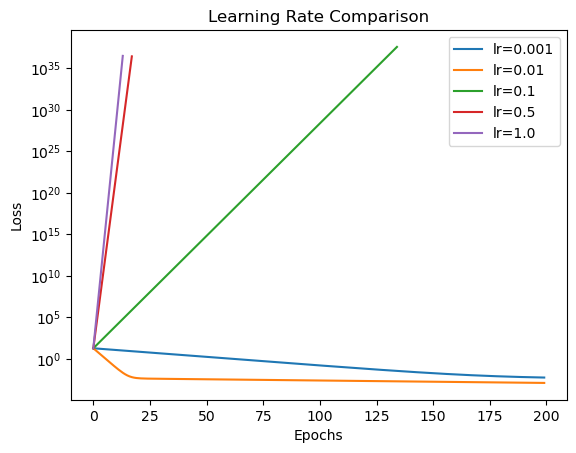

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0]
])

class LinearModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

learning_rate = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
epochs = 200

all_losses = {}

for lr in learning_rate:
    
    torch.manual_seed(42)

    model = LinearModel()

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr
            )

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X)
        loss = loss_fn(predictions, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    all_losses[lr] = losses

    print(
            f"lr={lr:<5}"
            f"final loss={losses[-1]:.8f}"
        )

# グラフ
for lr, losses in all_losses.items():
    plt.plot(losses, label=f"lr={lr}")

plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [47]:
threshold = 0.001

for lr, losses in all_losses.items():

    reached_epoch = None
    for epoch, loss in enumerate(losses):
        if loss < threshold:
            reached_epoch = epoch
            break
    if reached_epoch is None:
        print(f"lr={lr}: thresholdに到達しなかった")
    else:
        print(
            f"lr={lr}: "
            f"Epoch {reached_epoch} で "
            f"Loss < {threshold}"
        )



lr=0.001: thresholdに到達しなかった
lr=0.01: thresholdに到達しなかった
lr=0.1: thresholdに到達しなかった
lr=0.5: thresholdに到達しなかった
lr=1.0: thresholdに到達しなかった
